<a href="https://colab.research.google.com/github/RazyAnas/MachineLearning/blob/main/One_Hot_Encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

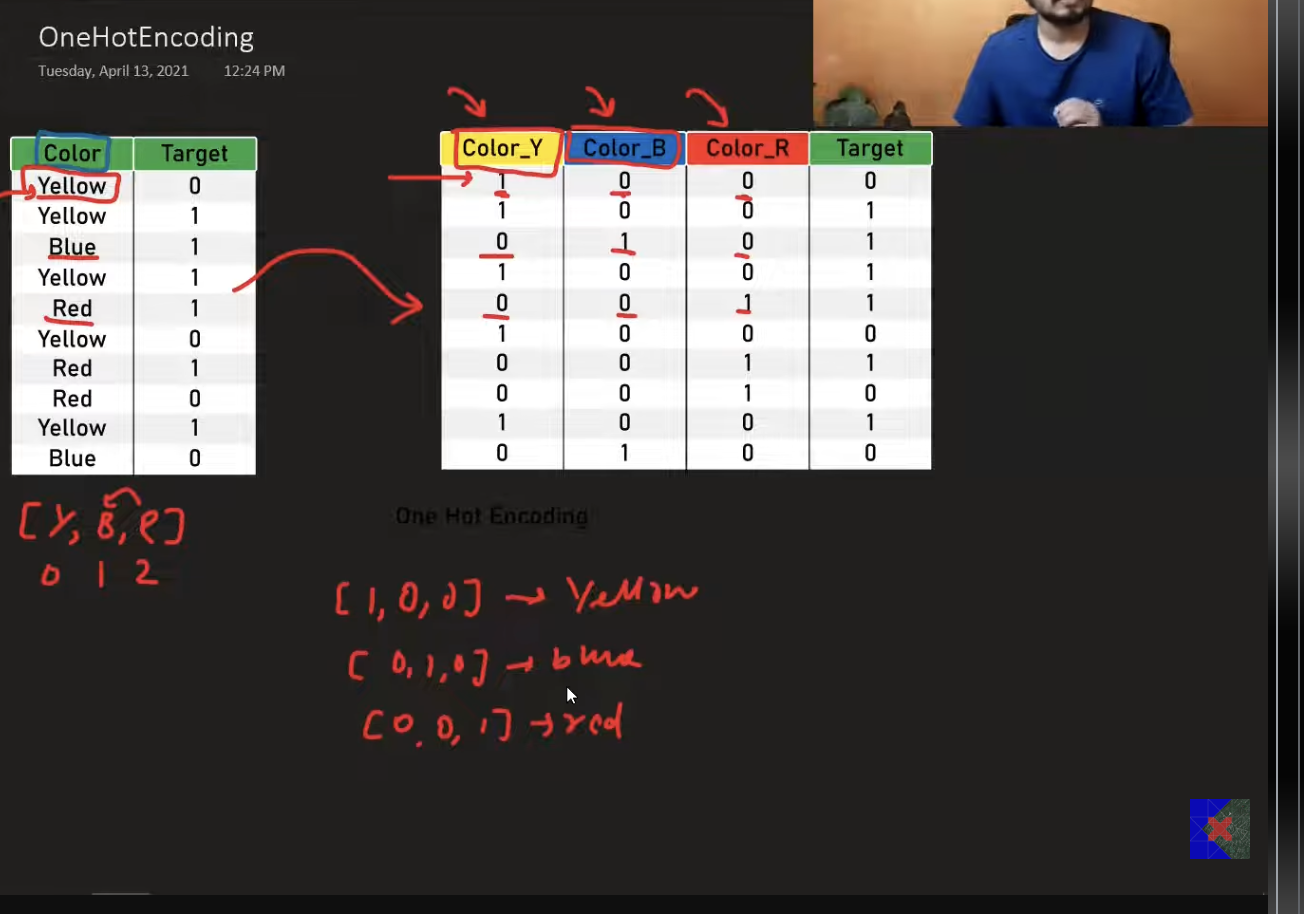

jitna categories utna columns

Dummy varibale trap
remove one column from 3 columns we got

n cols

n-1 cols keep

Concept: Multicollinearity

Input columns, mathematical relation if they have -> dependent and wrong

Input columns should not have mathematical relations -> otheriwse problems for linear models

therefore, remove one columns

But how will we represent -> if both col 0 then other is definitely 1

Example:

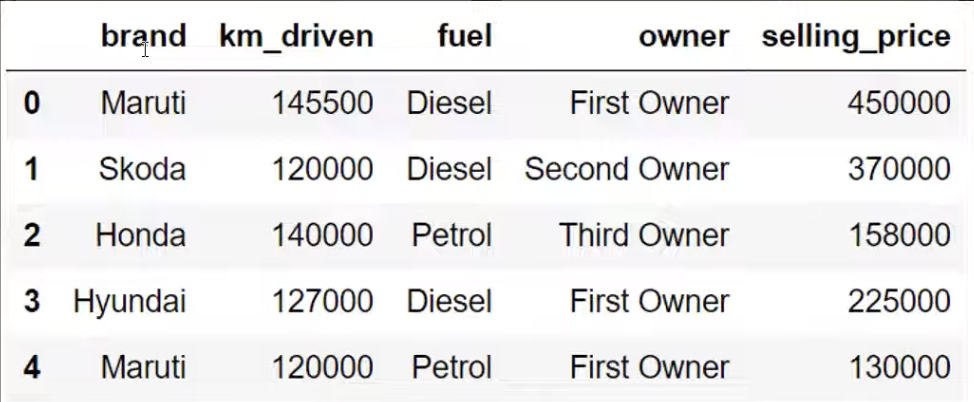

Brand is nominal categorical data -> 40 Brands --> OHE

Lots of cols: Some too much some too less:

Frequent categ keep

others -> combine and create one cagtegory



In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day27-one-hot-encoding/cars.csv')

In [4]:
df.head()

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000


In [7]:
df['brand'].value_counts()

,count
brand,
Maruti,2448
Hyundai,1415
Mahindra,772
Tata,734
Toyota,488
Honda,467
Ford,397
Chevrolet,230
Renault,228


In [8]:
df['fuel'].nunique()

4

# 1. OneHotEncoding using pandas

In [9]:
pd.get_dummies(df, columns=['fuel', 'owner'])

,brand,km_driven,selling_price,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,False,True,False,False,True,False,False,False,False
1,Skoda,120000,370000,False,True,False,False,False,False,True,False,False
2,Honda,140000,158000,False,False,False,True,False,False,False,False,True
3,Hyundai,127000,225000,False,True,False,False,True,False,False,False,False
4,Maruti,120000,130000,False,False,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,False,True,True,False,False,False,False
8124,Hyundai,119000,135000,False,True,False,False,False,True,False,False,False
8125,Maruti,120000,382000,False,True,False,False,True,False,False,False,False
8126,Tata,25000,290000,False,True,False,False,True,False,False,False,False


# 2. K-1 OneHotEncoding

remove multicolinearity problem

In [10]:
pd.get_dummies(df, columns=['fuel', 'owner'], drop_first=True)

,brand,km_driven,selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,True,False,False,False,False,False,False
1,Skoda,120000,370000,True,False,False,False,True,False,False
2,Honda,140000,158000,False,False,True,False,False,False,True
3,Hyundai,127000,225000,True,False,False,False,False,False,False
4,Maruti,120000,130000,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,True,False,False,False,False
8124,Hyundai,119000,135000,True,False,False,True,False,False,False
8125,Maruti,120000,382000,True,False,False,False,False,False,False
8126,Tata,25000,290000,True,False,False,False,False,False,False


In [11]:
# pandas dont remember, so we dont use it machine learning
# we use scikit learning class onehotencoder class

# 3. OneHotEncoding using Sklearn

step 1: train test split

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,0:4], df.iloc[:, -1], test_size=0.2, random_state=2)

In [15]:
X_test.head()

,brand,km_driven,fuel,owner
606,Hyundai,80000,Petrol,First Owner
7575,Mahindra,70000,Diesel,Second Owner
7705,Toyota,68089,Petrol,First Owner
4305,Hyundai,70000,Petrol,Second Owner
2685,Mahindra,97000,Diesel,Second Owner


In [16]:
from sklearn.preprocessing import OneHotEncoder

In [43]:
ohe = OneHotEncoder(drop='first', sparse_output=False, dtype=np.int32)

In [44]:
X_train_new = ohe.fit_transform(X_train[['fuel', 'owner']])

In [45]:
X_test_new = ohe.transform(X_test[['fuel', 'owner']])

In [46]:
X_train[['brand', 'km_driven']].values

array([['Hyundai', 35000],
       ['Jeep', 60000],
       ['Hyundai', 25000],
       ...,
       ['Tata', 15000],
       ['Maruti', 32500],
       ['Isuzu', 121000]], dtype=object)

In [47]:
np.hstack((X_train[['brand', 'km_driven']].values, X_train_new))

array([['Hyundai', 35000, 1, ..., 0, 0, 0],
       ['Jeep', 60000, 1, ..., 0, 0, 0],
       ['Hyundai', 25000, 0, ..., 0, 0, 0],
       ...,
       ['Tata', 15000, 0, ..., 0, 0, 0],
       ['Maruti', 32500, 1, ..., 1, 0, 0],
       ['Isuzu', 121000, 1, ..., 0, 0, 0]], dtype=object)

# 4. OneHotEncoding with Top Categories

In [63]:
counts = df['brand'].value_counts()

In [56]:
threshold=100

In [67]:
repl = counts[counts <= threshold].index

In [73]:
pd.get_dummies(df['brand'].replace(repl, 'uncommon'), dtype='int')

,BMW,Chevrolet,Ford,Honda,Hyundai,Mahindra,Maruti,Renault,Skoda,Tata,Toyota,Volkswagen,uncommon
0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,0,0,0,0,1,0,0,0,0,0,0,0,0
8124,0,0,0,0,1,0,0,0,0,0,0,0,0
8125,0,0,0,0,0,0,1,0,0,0,0,0,0
8126,0,0,0,0,0,0,0,0,0,1,0,0,0
